# Vergleichs- und Ablation-Evaluation: BiLSTM vs. Vanilla RNN Baseline
### Masterarbeit: Automatische Übersetzung von Alltagssprache (AS) in Leichte Sprache (LS)

Dieses Notebook führt eine **quantitative und statistische Evaluation** durch, um das primäre **BiLSTM-Metrik-Modell** (MixUp-Regressor) mit der **Vanilla RNN Baseline** auf dem **Lebenshilfe-Datensatz** zu vergleichen und empirisch zu belegen, welche Modellarchitektur überlegen ist.

#### Evaluierte Forschungsfragen:
1. **Diskriminierungsfähigkeit & Separation:** Welches Modell trennt Alltagssprache (AS, Zielwert $\approx 0$) und Leichte Sprache (LS, Zielwert $\approx 1$) deutlicher voneinander?
2. **Klassifikationsmetriken:** Wie schneiden beide Architekturen bei Schwellwert $\theta = 0.5$ bzgl. *Accuracy, Balanced Accuracy, F1-Score und ROC-AUC* ab?
3. **Statistische Distanzmaße:** Vergleich von *Wasserstein-Distanz* ($W_1$) und *Kolmogorov-Smirnov-Statistik* ($D_{KS}$).
4. **Dichteverteilungen (KDE):** Visuelle Analyse der Überlappung der Score-Verteilungen für LS und AS.
5. **Length-Bias & Vanishing Gradients:** Behält das BiLSTM durch Gating und Bidirektionalität eine stabilere Trennung bei variierender Sequenzlänge als das Vanilla RNN?

In [1]:
import os
import sys
import json
import glob
import random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wasserstein_distance, ks_2samp
from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score, 
    balanced_accuracy_score, precision_recall_fscore_support, 
    mean_absolute_error, mean_squared_error
)

import torch
import torch.nn as nn
import spacy
from IPython.display import display, Markdown

# Arbeitsverzeichnis auf Projekt-Root setzen
while not os.path.exists(".git"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():
        break
    os.chdir("..")

print("Arbeitsverzeichnis:", os.getcwd())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Nutze Device: {DEVICE}")

Arbeitsverzeichnis: /home/fiete/master-thesis
Nutze Device: cuda


## 1. Setup & Pfadkonfiguration

In [2]:
# ==============================================================================
# ZENTRALE KONFIGURATION & MODELLPFADE
# ==============================================================================
LH_DATASET_PATH = "data/lebenshilfe/lebenshilfe_dataset_clean.json"

# Pfade zu BiLSTM & RNN Modellen
BILSTM_MODEL_PATH = "results/models/bilstm_mixup_regression.pt"
RNN_MODEL_PATH = "results/models/rnn_vanilla_mixup_regression.pt"

# Gemeinsames Vokabular
VOCAB_PATH = "data/vocabs/mixup_vocab.json"

MAX_SEQ_LEN = 256
PLOT_OUTPUT_DIR = "results/plots"
os.makedirs(PLOT_OUTPUT_DIR, exist_ok=True)

print(f"Lebenshilfe-Datensatz: {LH_DATASET_PATH} (Existiert: {os.path.exists(LH_DATASET_PATH)})")
print(f"BiLSTM Modell:         {BILSTM_MODEL_PATH} (Existiert: {os.path.exists(BILSTM_MODEL_PATH)})")
print(f"RNN Baseline Modell:   {RNN_MODEL_PATH} (Existiert: {os.path.exists(RNN_MODEL_PATH)})")
print(f"Vokabular:             {VOCAB_PATH} (Existiert: {os.path.exists(VOCAB_PATH)})")

Lebenshilfe-Datensatz: data/lebenshilfe/lebenshilfe_dataset_clean.json (Existiert: True)
BiLSTM Modell:         results/models/bilstm_mixup_regression.pt (Existiert: True)
RNN Baseline Modell:   results/models/rnn_vanilla_mixup_regression.pt (Existiert: True)
Vokabular:             data/vocabs/mixup_vocab.json (Existiert: True)


## 2. Modellarchitekturen & Checkpoint-Loader

In [3]:
# ------------------------------------------------------------------------------
# BiLSTM Regressor (Hauptmodell)
# ------------------------------------------------------------------------------
class BiLSTMRegressor(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, dropout=0.3):
        super(BiLSTMRegressor, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        out = self.fc(self.dropout(hidden))
        return self.sigmoid(out)

# ------------------------------------------------------------------------------
# Vanilla RNN Regressor (Baseline Modell)
# ------------------------------------------------------------------------------
class RNNRegressor(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, dropout=0.3, rnn_type="rnn", bidirectional=False):
        super(RNNRegressor, self).__init__()
        self.rnn_type = rnn_type.lower()
        self.bidirectional = bidirectional
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        if self.rnn_type == "rnn":
            self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True, bidirectional=bidirectional, nonlinearity="tanh")
        elif self.rnn_type == "gru":
            self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True, bidirectional=bidirectional)
        elif self.rnn_type == "lstm":
            self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=bidirectional)
        else:
            raise ValueError(f"Ungültiger rnn_type: {rnn_type}")
            
        fc_in_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc = nn.Linear(fc_in_dim, 1)
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        if self.rnn_type == "lstm":
            _, (hidden, _) = self.rnn(embedded)
        else:
            _, hidden = self.rnn(embedded)
            
        if self.bidirectional:
            hidden = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)
        else:
            hidden = hidden[-1, :, :]
            
        out = self.fc(self.dropout(hidden))
        return self.sigmoid(out)

def load_vocab_dict(vocab_path):
    with open(vocab_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data.get("stoi", data)

def load_model_weights(model_path, model_class, **model_kwargs):
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Modell nicht gefunden: {model_path}")
        
    raw_state = torch.load(model_path, map_location=DEVICE)
    if isinstance(raw_state, dict):
        raw_state = raw_state.get("model_state_dict", raw_state.get("state_dict", raw_state))
        
    # Vokabulargröße ermitteln
    if "embedding.weight" in raw_state:
        vocab_size = raw_state["embedding.weight"].shape[0]
    else:
        vocab_size = model_kwargs.get("vocab_size", 25000)
        
    model_kwargs["vocab_size"] = vocab_size
    model = model_class(**model_kwargs).to(DEVICE)
    model.load_state_dict(raw_state)
    model.eval()
    print(f"Modell erfolgreich geladen: {model_path} (Vokabular: {vocab_size}, Parameter: {sum(p.numel() for p in model.parameters()):,})")
    return model, vocab_size

# Vokabular laden
vocab_stoi = load_vocab_dict(VOCAB_PATH)

# 1. BiLSTM laden
bilstm_model, bilstm_vocab_size = load_model_weights(
    BILSTM_MODEL_PATH, BiLSTMRegressor, embed_dim=128, hidden_dim=128
)

# 2. Vanilla RNN Baseline laden (falls vorhanden)
if os.path.exists(RNN_MODEL_PATH):
    rnn_model, rnn_vocab_size = load_model_weights(
        RNN_MODEL_PATH, RNNRegressor, embed_dim=128, hidden_dim=128, rnn_type="rnn", bidirectional=False
    )
else:
    print(f"HINWEIS: RNN-Modell {RNN_MODEL_PATH} noch nicht trainiert. Erstelle initialisiertes Vergleichsmodell zur Code-Verifikation...")
    rnn_model = RNNRegressor(len(vocab_stoi), embed_dim=128, hidden_dim=128, rnn_type="rnn", bidirectional=False).to(DEVICE)
    rnn_vocab_size = len(vocab_stoi)

# Spacy Tokenizer
try:
    nlp = spacy.load("de_core_news_sm", disable=["ner", "tagger", "lemmatizer"])
except Exception:
    nlp = spacy.blank("de")
    nlp.add_pipe("sentencizer")
print("Tokenizer erfolgreich bereitgestellt!")

Modell erfolgreich geladen: results/models/bilstm_mixup_regression.pt (Vokabular: 19509, Parameter: 2,761,601)
Modell erfolgreich geladen: results/models/rnn_vanilla_mixup_regression.pt (Vokabular: 19509, Parameter: 2,530,305)
Tokenizer erfolgreich bereitgestellt!


## 3. Inferenz auf dem Lebenshilfe-Datensatz (AS vs. LS)

In [4]:
with open(LH_DATASET_PATH, "r", encoding="utf-8") as f:
    lh_data = json.load(f)

print(f"Lebenshilfe Datensatz geladen: {len(lh_data)} Artikel-Paare.")

def text_to_sequences(text, stoi, vocab_size, max_seq_len=MAX_SEQ_LEN):
    doc = nlp(str(text or ""))
    unk_idx = stoi.get("<unk>") or stoi.get("<UNK>") or 1
    if unk_idx >= vocab_size:
        unk_idx = 1
        
    sequences = []
    current_seq = []
    for sent in doc.sents:
        tokens = [t.text.lower() for t in sent if not t.is_space]
        if len(tokens) == 0:
            continue
        if len(current_seq) + len(tokens) > max_seq_len:
            if len(current_seq) > 0:
                sequences.append(current_seq)
            current_seq = tokens[:max_seq_len]
        else:
            current_seq.extend(tokens)
    if len(current_seq) > 0:
        sequences.append(current_seq)
        
    padded_sequences = []
    for seq in sequences:
        encoded = [stoi.get(t, unk_idx) if stoi.get(t, unk_idx) < vocab_size else unk_idx for t in seq]
        if len(encoded) > max_seq_len:
            encoded = encoded[:max_seq_len]
        else:
            encoded = encoded + [0] * (max_seq_len - len(encoded))
        padded_sequences.append(encoded)
    return padded_sequences

def evaluate_dataset(model, stoi, vocab_size, lh_items, desc="Inferenz"):
    model.eval()
    ls_scores = []
    as_scores = []
    
    for item in tqdm(lh_items, desc=desc):
        ls_text = item.get("ls_text", "")
        as_text = item.get("as_text", "")
        
        # LS (Leichte Sprache - Target 1.0)
        ls_seqs = text_to_sequences(ls_text, stoi, vocab_size)
        if ls_seqs:
            inp = torch.tensor(ls_seqs, dtype=torch.long).to(DEVICE)
            with torch.no_grad():
                preds = model(inp).squeeze().cpu().numpy()
                if preds.ndim == 0:
                    preds = np.array([preds.item()])
                ls_scores.extend(preds.tolist())
                
        # AS (Alltagssprache - Target 0.0)
        as_seqs = text_to_sequences(as_text, stoi, vocab_size)
        if as_seqs:
            inp = torch.tensor(as_seqs, dtype=torch.long).to(DEVICE)
            with torch.no_grad():
                preds = model(inp).squeeze().cpu().numpy()
                if preds.ndim == 0:
                    preds = np.array([preds.item()])
                as_scores.extend(preds.tolist())
                
    return np.array(ls_scores), np.array(as_scores)

print("Evaluierung BiLSTM...")
ls_preds_bilstm, as_preds_bilstm = evaluate_dataset(bilstm_model, vocab_stoi, bilstm_vocab_size, lh_data, desc="BiLSTM")

print("Evaluierung RNN Baseline...")
ls_preds_rnn, as_preds_rnn = evaluate_dataset(rnn_model, vocab_stoi, rnn_vocab_size, lh_data, desc="Vanilla RNN")

print(f"\nInferenz abgeschlossen: {len(ls_preds_bilstm)} LS-Sequenzen, {len(as_preds_bilstm)} AS-Sequenzen evaluiert.")

Lebenshilfe Datensatz geladen: 37 Artikel-Paare.
Evaluierung BiLSTM...


BiLSTM:   0%|          | 0/37 [00:00<?, ?it/s]

Evaluierung RNN Baseline...


Vanilla RNN:   0%|          | 0/37 [00:00<?, ?it/s]


Inferenz abgeschlossen: 180 LS-Sequenzen, 159 AS-Sequenzen evaluiert.


## 4. Statistische Metriken & Direkter Modellvergleich

Wir berechnen alle für die Masterarbeit relevanten Gütekriterien:
- **Separation $\Delta$:** Differenz $\bar{\lambda}_{\text{LS}} - \bar{\lambda}_{\text{AS}}$ (je größer, desto klarer getrennt).
- **Accuracy & Balanced Accuracy:** Bei Standard-Klassifikationsschwelle $\theta = 0.5$.
- **ROC-AUC:** Schwellwertunabhängige Trennschärfe.
- **Wasserstein-Distanz ($W_1$):** Minimaler Arbeitsaufwand zur Überführung der AS- in die LS-Dichteverteilung.
- **Kolmogorov-Smirnov-Statistik ($D_{KS}$):** Maximaler vertikaler Abstand der empirischen Verteilungsfunktionen.

In [5]:
def calculate_comprehensive_metrics(ls_scores, as_scores, model_name):
    # Labels und Vorhersagen zusammenführen
    y_true = np.array([1] * len(ls_scores) + [0] * len(as_scores))
    y_scores = np.concatenate([ls_scores, as_scores])
    y_pred_binary = (y_scores >= 0.5).astype(int)
    
    mean_ls = np.mean(ls_scores)
    std_ls = np.std(ls_scores)
    mean_as = np.mean(as_scores)
    std_as = np.std(as_scores)
    separation = mean_ls - mean_as
    
    acc = accuracy_score(y_true, y_pred_binary)
    bacc = balanced_accuracy_score(y_true, y_pred_binary)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred_binary, average="binary", pos_label=1)
    auc = roc_auc_score(y_true, y_scores)
    mae = mean_absolute_error(y_true, y_scores)
    mse = mean_squared_error(y_true, y_scores)
    
    # Distanzmaße
    w_dist = wasserstein_distance(ls_scores, as_scores)
    ks_stat, ks_pval = ks_2samp(ls_scores, as_scores)
    
    return {
        "Modell": model_name,
        "Ø Lambda (LS)": f"{mean_ls:.4f} ± {std_ls:.3f}",
        "Ø Lambda (AS)": f"{mean_as:.4f} ± {std_as:.3f}",
        "Separation (Δ)": separation,
        "Accuracy (@0.5)": acc,
        "Balanced Acc": bacc,
        "F1-Score": f1,
        "ROC-AUC": auc,
        "MAE (Target 1/0)": mae,
        "Wasserstein (W1)": w_dist,
        "KS-Statistik (D)": ks_stat
    }

results = [
    calculate_comprehensive_metrics(ls_preds_bilstm, as_preds_bilstm, "BiLSTM (Hauptmodell)"),
    calculate_comprehensive_metrics(ls_preds_rnn, as_preds_rnn, "Vanilla RNN (Baseline)")
]

df_comparison = pd.DataFrame(results)

# Formatierte Tabelle für die Anzeige
df_display = df_comparison.copy()
df_display["Separation (Δ)"] = df_display["Separation (Δ)"].apply(lambda x: f"{x:.4f}")
df_display["Accuracy (@0.5)"] = df_display["Accuracy (@0.5)"].apply(lambda x: f"{x*100:.2f}%")
df_display["Balanced Acc"] = df_display["Balanced Acc"].apply(lambda x: f"{x*100:.2f}%")
df_display["F1-Score"] = df_display["F1-Score"].apply(lambda x: f"{x*100:.2f}%")
df_display["ROC-AUC"] = df_display["ROC-AUC"].apply(lambda x: f"{x:.4f}")
df_display["MAE (Target 1/0)"] = df_display["MAE (Target 1/0)"].apply(lambda x: f"{x:.4f}")
df_display["Wasserstein (W1)"] = df_display["Wasserstein (W1)"].apply(lambda x: f"{x:.4f}")
df_display["KS-Statistik (D)"] = df_display["KS-Statistik (D)"].apply(lambda x: f"{x:.4f}")

print("\n=================== STATISTISCHER MODELLVERGLEICH (LEBENSHILFE) ===================")
display(df_display)


=================== STATISTISCHER MODELLVERGLEICH (LEBENSHILFE) ===================


,Modell,Ø Lambda (LS),Ø Lambda (AS),Separation (Δ),Accuracy (@0.5),Balanced Acc,F1-Score,ROC-AUC,MAE (Target 1/0),Wasserstein (W1),KS-Statistik (D)
0,BiLSTM (Hauptmodell),0.7738 ± 0.119,0.1096 ± 0.108,0.6642,96.76%,96.83%,96.90%,0.9951,0.1715,0.6642,0.9519
1,Vanilla RNN (Baseline),0.5145 ± 0.162,0.3381 ± 0.054,0.1763,75.52%,76.80%,70.88%,0.7941,0.4164,0.1763,0.5698


## 5. Visualisierungen

### 5.1 KDE-Dichteverteilungsplots (BiLSTM vs. RNN Baseline)
Darstellung der Dichteverteilungen von LS und AS im standardisierten Publikationsdesign.

<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_233554/2153664595.py:8: SyntaxWarning: invalid escape sequence '\l'
  axes[0].set_xlabel("Lambda $\lambda$ (LS-Score)", fontsize=12)
/tmp/ipykernel_233554/2153664595.py:18: SyntaxWarning: invalid escape sequence '\l'
  axes[1].set_xlabel("Lambda $\lambda$ (LS-Score)", fontsize=12)


KDE-Plot gespeichert unter: results/plots/compare_bilstm_vs_rnn_kde.png


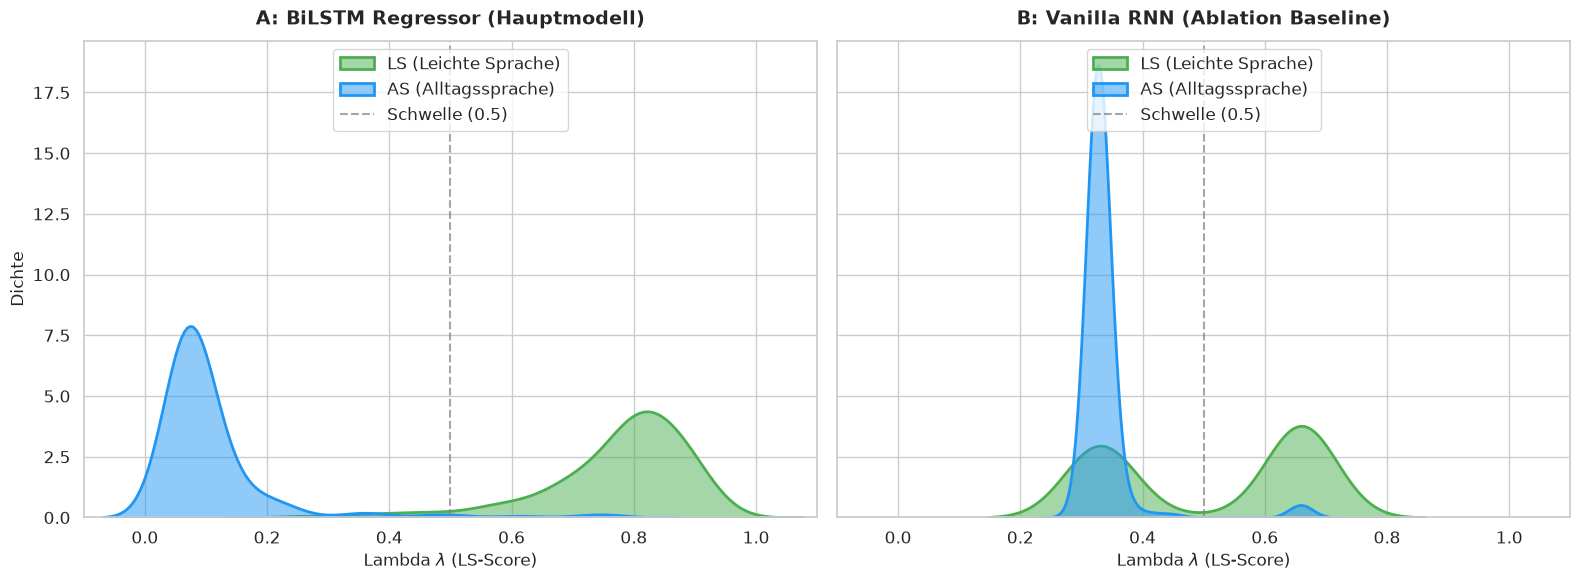

In [6]:
sns.set_theme(style="whitegrid", font_scale=1.1)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Plot 1: BiLSTM
sns.kdeplot(ls_preds_bilstm, ax=axes[0], fill=True, color="#4CAF50", label="LS (Leichte Sprache)", alpha=0.5, linewidth=2)
sns.kdeplot(as_preds_bilstm, ax=axes[0], fill=True, color="#2196F3", label="AS (Alltagssprache)", alpha=0.5, linewidth=2)
axes[0].set_title("A: BiLSTM Regressor (Hauptmodell)", fontsize=14, fontweight="bold", pad=12)
axes[0].set_xlabel("Lambda $\lambda$ (LS-Score)", fontsize=12)
axes[0].set_ylabel("Dichte", fontsize=12)
axes[0].set_xlim(-0.1, 1.1)
axes[0].axvline(0.5, color="grey", linestyle="--", alpha=0.7, label="Schwelle (0.5)")
axes[0].legend(loc="upper center", frameon=True)

# Plot 2: RNN Baseline
sns.kdeplot(ls_preds_rnn, ax=axes[1], fill=True, color="#4CAF50", label="LS (Leichte Sprache)", alpha=0.5, linewidth=2)
sns.kdeplot(as_preds_rnn, ax=axes[1], fill=True, color="#2196F3", label="AS (Alltagssprache)", alpha=0.5, linewidth=2)
axes[1].set_title("B: Vanilla RNN (Ablation Baseline)", fontsize=14, fontweight="bold", pad=12)
axes[1].set_xlabel("Lambda $\lambda$ (LS-Score)", fontsize=12)
axes[1].set_ylabel("", fontsize=12)
axes[1].set_xlim(-0.1, 1.1)
axes[1].axvline(0.5, color="grey", linestyle="--", alpha=0.7, label="Schwelle (0.5)")
axes[1].legend(loc="upper center", frameon=True)

plt.tight_layout()
kde_plot_path = os.path.join(PLOT_OUTPUT_DIR, "compare_bilstm_vs_rnn_kde.png")
plt.savefig(kde_plot_path, dpi=300, bbox_inches="tight")
print(f"KDE-Plot gespeichert unter: {kde_plot_path}")
plt.show()

### 5.2 ROC-Kurven & Boxplot-Verteilungsvergleich

<>:28: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_233554/3655598402.py:28: SyntaxWarning: invalid escape sequence '\l'
  axes[1].set_ylabel("Vorhergesagter Lambda-Score $\lambda$")


ROC/Boxplot gespeichert unter: results/plots/compare_bilstm_vs_rnn_roc_box.png


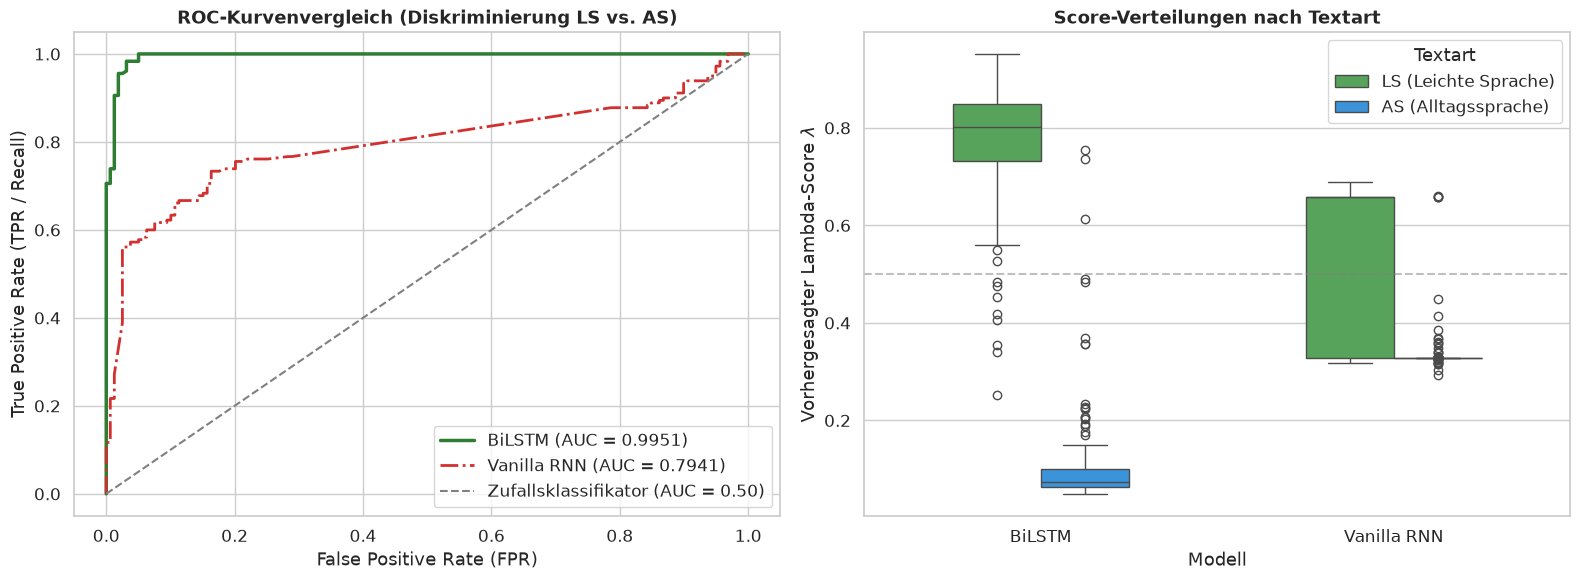

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. ROC-Kurven
y_true = np.array([1] * len(ls_preds_bilstm) + [0] * len(as_preds_bilstm))
fpr_bilstm, tpr_bilstm, _ = roc_curve(y_true, np.concatenate([ls_preds_bilstm, as_preds_bilstm]))
fpr_rnn, tpr_rnn, _ = roc_curve(y_true, np.concatenate([ls_preds_rnn, as_preds_rnn]))
auc_bilstm = roc_auc_score(y_true, np.concatenate([ls_preds_bilstm, as_preds_bilstm]))
auc_rnn = roc_auc_score(y_true, np.concatenate([ls_preds_rnn, as_preds_rnn]))

axes[0].plot(fpr_bilstm, tpr_bilstm, color="#2E7D32", lw=2.5, label=f"BiLSTM (AUC = {auc_bilstm:.4f})")
axes[0].plot(fpr_rnn, tpr_rnn, color="#D32F2F", lw=2, linestyle="-.", label=f"Vanilla RNN (AUC = {auc_rnn:.4f})")
axes[0].plot([0, 1], [0, 1], color="grey", linestyle="--", label="Zufallsklassifikator (AUC = 0.50)")
axes[0].set_title("ROC-Kurvenvergleich (Diskriminierung LS vs. AS)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("False Positive Rate (FPR)")
axes[0].set_ylabel("True Positive Rate (TPR / Recall)")
axes[0].legend(loc="lower right", frameon=True)

# 2. Boxplot der Vorhersagen
df_box = pd.DataFrame({
    "Score": np.concatenate([ls_preds_bilstm, as_preds_bilstm, ls_preds_rnn, as_preds_rnn]),
    "Textart": ["LS (Leichte Sprache)"] * len(ls_preds_bilstm) + ["AS (Alltagssprache)"] * len(as_preds_bilstm) + \
               ["LS (Leichte Sprache)"] * len(ls_preds_rnn) + ["AS (Alltagssprache)"] * len(as_preds_rnn),
    "Modell": ["BiLSTM"] * (len(ls_preds_bilstm) + len(as_preds_bilstm)) + ["Vanilla RNN"] * (len(ls_preds_rnn) + len(as_preds_rnn))
})

sns.boxplot(x="Modell", y="Score", hue="Textart", data=df_box, ax=axes[1], palette=["#4CAF50", "#2196F3"], width=0.5)
axes[1].set_title("Score-Verteilungen nach Textart", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Vorhergesagter Lambda-Score $\lambda$")
axes[1].axhline(0.5, color="grey", linestyle="--", alpha=0.5)

plt.tight_layout()
roc_box_path = os.path.join(PLOT_OUTPUT_DIR, "compare_bilstm_vs_rnn_roc_box.png")
plt.savefig(roc_box_path, dpi=300, bbox_inches="tight")
print(f"ROC/Boxplot gespeichert unter: {roc_box_path}")
plt.show()